### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpBinary, lpSum, LpMinimize, PULP_CBC_CMD, GLPK_CMD

np.random.seed(42)

### Sampling e, f and g

* We use a Multivariate Gaussian to sample e,f and g values with the specified covariance between them 

In [ ]:
# Number of instances
N = 5000

#### Parameters

In [ ]:
mean = [0.5, 0.5, 0.5]
cov = [[1, 0.5, 0], [0.5, 1, 0.05], [0, 0.05, 1]] 

In [ ]:
points = np.random.multivariate_normal(mean, cov, N)

gi = np.clip(points[:, 0], 0, 1)
fi = np.clip(points[:, 1], 0, 1)
ei = np.clip(points[:, 2], 0, 1)


### Budget

In [22]:
# Budget
BUDGET_PERC = 0.1
B = np.sum(ei) * BUDGET_PERC

### Solve the LP to get allocations

In [ ]:
# Cost coefficients
c = fi - gi

# Initialize problem
prob = LpProblem("Expert_Assignment_ILP", LpMinimize)

# Decision variables: Xi ∈ {0, 1}
X = [LpVariable(f'X_{i}', cat=LpBinary) for i in range(N)]

# Objective: minimize sum(gi + Xi*(fi - gi)) = constant + sum(Xi*(fi - gi))
prob += lpSum([c[i] * X[i] for i in range(N)])

# Constraint: total effort used by expert ≤ B
prob += lpSum([ei[i] * X[i] for i in range(N)]) <= B

# Solve
prob.solve(PULP_CBC_CMD(msg=1))  # Silent mode

# Extract results
Xi = np.array([int(X[i].varValue) if X[i].varValue is not None else 0 for i in range(N)])

### Allocation Visualization

In [ ]:
# DataFrame for analysis
df = pd.DataFrame({
    'gi': gi,
    'fi': fi,
    'ei': ei,
    'Xi': Xi
})
df['AssignedToExpert'] = df['Xi'] == 1

# === Visualization 1: Model vs Expert Loss ===
plt.figure(figsize=(10, 5))
colors = ['red' if x else 'blue' for x in df['AssignedToExpert']]
plt.scatter(df['gi'], df['fi'], c=colors, alpha=0.7)
plt.plot([0, 1], [0, 1], 'k--', label='fi = gi')
plt.xlabel('Model Loss (gi)')
plt.ylabel('Expert Loss (fi)')
plt.title('Model vs Expert Loss\n(Red: Expert, Blue: Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Visualization 2: Effort vs Loss Reduction ===
plt.figure(figsize=(10, 5))
plt.scatter(df['ei'], df['gi'] - df['fi'], c=colors, alpha=0.7)
# plt.plot([0, 1], [0, 1- 2*BUDGET_PERC], 'k--', label='Loss Reduction = 0')
plt.xlabel('Effort (ei)')
plt.ylabel('Loss Reduction (gi - fi)')
plt.title('Effort vs Loss Reduction\n(Red: Expert, Blue: Model)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Average Expert Assignment on Varying budget

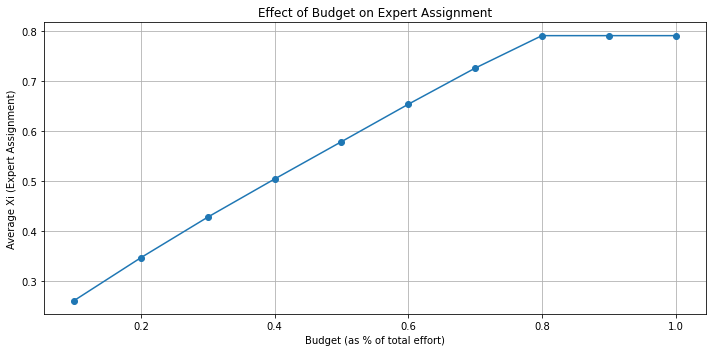

In [ ]:
budget_range = np.linspace(0.1, 1.0, 10)  # Budget from 10% to 100% of total effort
results = []
for budget in budget_range:
    # Solve the linear program for each budget
    B = np.sum(ei) * budget
    
    prob = LpProblem("Expert_Assignment_ILP", LpMinimize)

    # Decision variables: Xi ∈ {0, 1}
    X = [LpVariable(f'X_{i}', cat=LpBinary) for i in range(N)]

    # Objective: minimize sum(gi + Xi*(fi - gi)) = constant + sum(Xi*(fi - gi))
    prob += lpSum([c[i] * X[i] for i in range(N)])

    # Constraint: total effort used by expert ≤ B
    prob += lpSum([ei[i] * X[i] for i in range(N)]) <= B

    # Solve
    prob.solve(PULP_CBC_CMD(msg=0))  # Silent mode

    # Extract results
    Xi = np.array([X[i].varValue for i in range(N)], dtype=int)
    
    results.append((budget, Xi))
    
results_df = pd.DataFrame(results, columns=['Budget', 'Xi'])
results_df['Xi'] = results_df['Xi'].apply(lambda x: np.mean(x))  # Average Xi for each budget

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(results_df['Budget'], results_df['Xi'], marker='o')
plt.xlabel('Budget (as % of total effort)')
plt.ylabel('Average Xi (Expert Assignment)')
plt.title('Effect of Budget on Expert Assignment')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Define hard instances as those which have a high model loss and also require high effort to match the model loss with the expert loss
hard_instances = df[(df['gi'] > 0.8) & (df['ei'] > 1.0)]

# Define easy instances as those which have a low model loss and also require low effort to match the model loss with the expert loss
easy_instances = df[(df['gi'] < 0.5) & (df['ei'] < 0.5)]

# What should we call the instances that have a high model loss but require low effort to match the model loss with the expert loss?
# These could be considered as "low-effort high-loss" instances, as they have a high model loss but require low effort to match it with the expert loss.
low_effort_high_loss_instances = df[(df['gi'] > 0.8) & (df['ei'] < 0.5)]

# Want to visualize how does the paritioning of these instances look like when the budget is varied
# Create a new DataFrame to store the partitioning results
partitioning_results = pd.DataFrame(columns=['Budget', 'Hard Instances', 'Easy Instances', 'Low Effort High Loss Instances'])


# Loop through the budget range and count instances in each category
for budget in budget_range:
    B = np.sum(ei) * budget
    res = linprog(c=c, A_ub=A, b_ub=[B], bounds=bounds, method='highs')
    
    # Count instances in each category
    hard_count = len(hard_instances[(res.x > 0.5)])
    easy_count = len(easy_instances[(res.x > 0.5)])
    low_effort_high_loss_count = len(low_effort_high_loss_instances[(res.x > 0.5)])
    
    # Append results to the DataFrame
    partitioning_results = partitioning_results.append({
        'Budget': budget,
        'Hard Instances': hard_count,
        'Easy Instances': easy_count,
        'Low Effort High Loss Instances': low_effort_high_loss_count
    }, ignore_index=True)
    
# Plotting the partitioning results
plt.figure(figsize=(10, 5))
plt.plot(partitioning_results['Budget'], partitioning_results['Hard Instances'], marker='o', label='Hard Instances')
plt.plot(partitioning_results['Budget'], partitioning_results['Easy Instances'], marker='o', label='Easy Instances')
plt.plot(partitioning_results['Budget'], partitioning_results['Low Effort High Loss Instances'], marker='o', label='Low Effort High Loss Instances')
plt.xlabel('Budget (as % of total effort)')
plt.ylabel('Number of Instances')
plt.title('Partitioning of Instances by Budget')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()